In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:
train_data = datasets.CIFAR10(root='cifar_d',train=True,download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root='cifar_d',train=False,download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]


In [3]:
example = train_data.classes
example

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [4]:
len(example)

10

In [5]:
train = DataLoader(train_data,batch_size=64,shuffle=True)
test = DataLoader(test_data,batch_size=64)

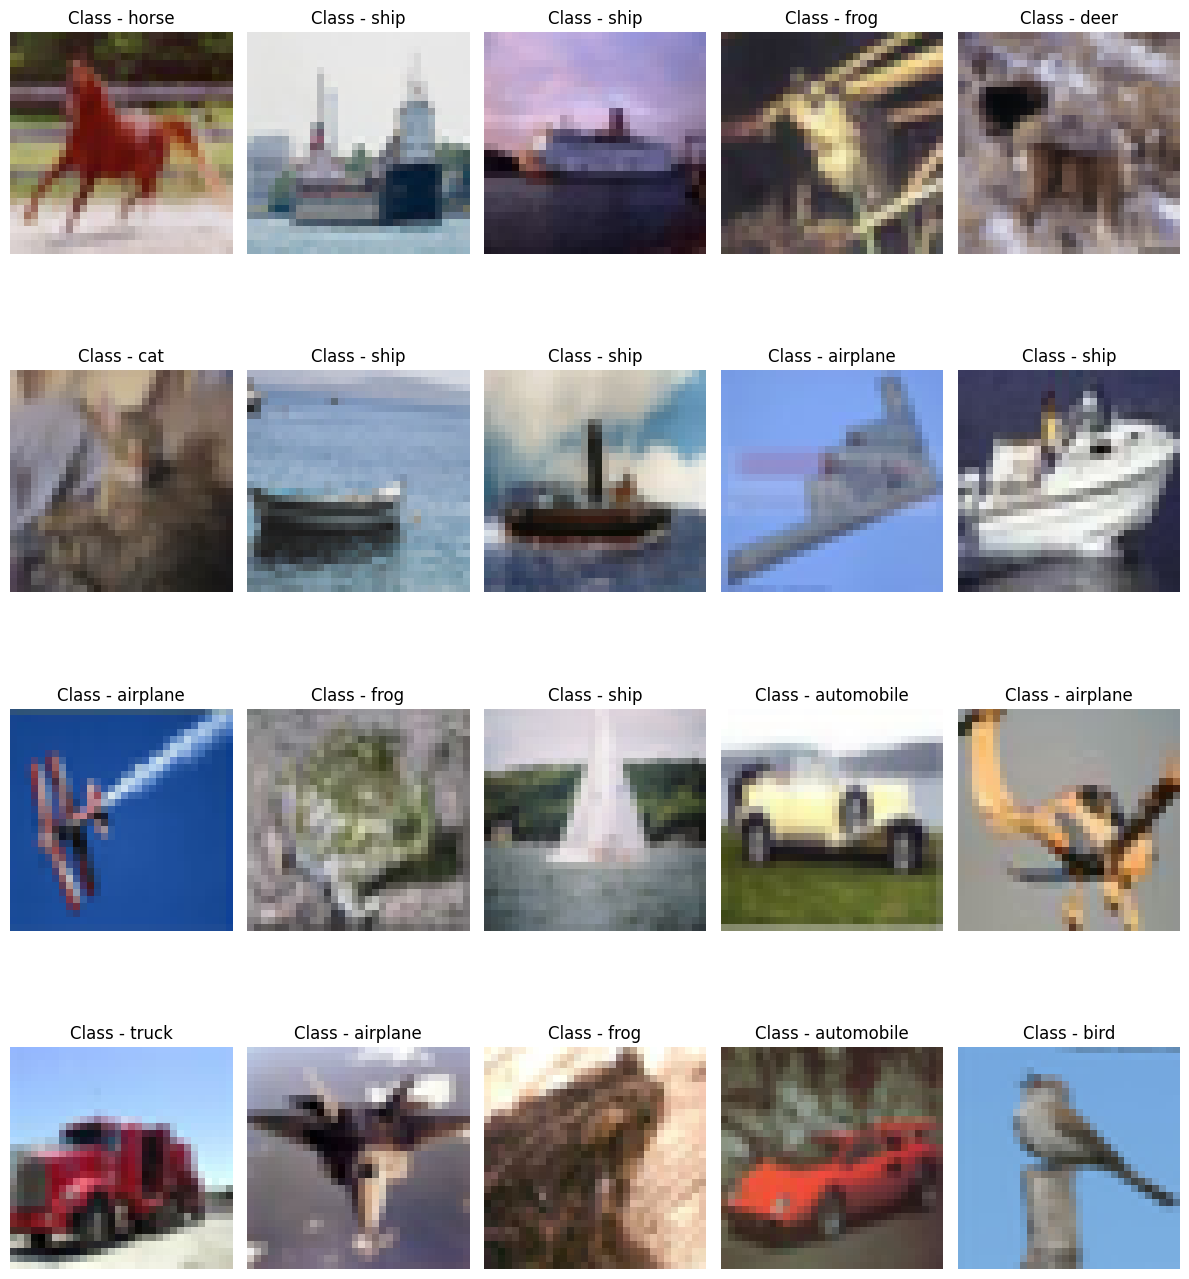

In [6]:
image, label = next(iter(train))
plt.figure(figsize=(12,16))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Class - {example[label[i]]}')
    plt.axis('off')
    plt.tight_layout()
plt.show()

In [7]:
class CifarClassifaction(nn.Module):
  def __init__(self):
    super().__init__()

    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),#32x32
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),#16x16
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),#8x8
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 4 * 4, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )

  def forward(self, image):
    image = self.first(image)
    image = self.second(image)
    return image

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
device

device(type='cuda')

In [10]:
model = CifarClassifaction().to(device)

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
for epoch in range(50):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f'Epoch {epoch + 1}, losses: {round(total_loss, 2)}')

Epoch 1, losses: 1187.66
Epoch 2, losses: 846.79
Epoch 3, losses: 701.33
Epoch 4, losses: 609.63
Epoch 5, losses: 541.69
Epoch 6, losses: 476.06
Epoch 7, losses: 423.74
Epoch 8, losses: 374.44
Epoch 9, losses: 325.68
Epoch 10, losses: 284.42
Epoch 11, losses: 244.57
Epoch 12, losses: 209.61
Epoch 13, losses: 174.07
Epoch 14, losses: 155.31
Epoch 15, losses: 132.76
Epoch 16, losses: 116.18
Epoch 17, losses: 102.8
Epoch 18, losses: 93.86
Epoch 19, losses: 78.53
Epoch 20, losses: 87.25
Epoch 21, losses: 76.19
Epoch 22, losses: 69.13
Epoch 23, losses: 70.75
Epoch 24, losses: 60.54
Epoch 25, losses: 64.68
Epoch 26, losses: 62.59
Epoch 27, losses: 54.16
Epoch 28, losses: 61.41
Epoch 29, losses: 60.09
Epoch 30, losses: 50.61
Epoch 31, losses: 63.22
Epoch 32, losses: 42.33
Epoch 33, losses: 57.25
Epoch 34, losses: 52.18
Epoch 35, losses: 46.67
Epoch 36, losses: 53.74
Epoch 37, losses: 41.89
Epoch 38, losses: 45.24
Epoch 39, losses: 50.57
Epoch 40, losses: 50.89
Epoch 41, losses: 41.68
Epoch 42

In [13]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    predicted = torch.argmax(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the test data model: {round(accuracy, 2)}%')

Accuracy of the test data model: 73.08%


In [23]:
torch.save(model.state_dict(), 'cifar_model.pth')

In [14]:
class CifarClassifaction2(nn.Module):
  def __init__(self):
    super().__init__()

    self.first = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),#32x32
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 16 * 16, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, image):
    image = self.first(image)
    image = self.second(image)
    return image

In [15]:
model2 = CifarClassifaction2().to(device)

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

In [22]:
for epoch in range(40):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f'Epoch {epoch + 1}, losses: {round(total_loss, 2)}')

Epoch 1, losses: 34.39
Epoch 2, losses: 34.4
Epoch 3, losses: 34.4
Epoch 4, losses: 34.47
Epoch 5, losses: 34.4
Epoch 6, losses: 34.39
Epoch 7, losses: 34.39
Epoch 8, losses: 34.4
Epoch 9, losses: 34.4
Epoch 10, losses: 34.51
Epoch 11, losses: 34.43
Epoch 12, losses: 34.4
Epoch 13, losses: 34.39
Epoch 14, losses: 34.4
Epoch 15, losses: 34.4
Epoch 16, losses: 34.49
Epoch 17, losses: 34.4
Epoch 18, losses: 34.62
Epoch 19, losses: 34.4
Epoch 20, losses: 34.4
Epoch 21, losses: 34.4
Epoch 22, losses: 34.39
Epoch 23, losses: 34.51
Epoch 24, losses: 34.4
Epoch 25, losses: 34.39
Epoch 26, losses: 34.39
Epoch 27, losses: 34.4
Epoch 28, losses: 34.39
Epoch 29, losses: 34.39
Epoch 30, losses: 34.42
Epoch 31, losses: 34.39
Epoch 32, losses: 34.4
Epoch 33, losses: 34.39
Epoch 34, losses: 34.41
Epoch 35, losses: 34.4
Epoch 36, losses: 34.43
Epoch 37, losses: 34.4
Epoch 38, losses: 34.4
Epoch 39, losses: 34.4
Epoch 40, losses: 34.4


In [21]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    predicted = torch.argmax(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the test data model: {round(accuracy, 2)}%')

Accuracy of the test data model: 73.08%


In [19]:
torch.save(model.state_dict(), 'cifar_model.pth')